# Outliers and edge cases

The first three notebooks describe the typical listing so this one
describes the atypical: where the long tails live, what the model
deliberately abstains on, where the residuals concentrate, and which
subsets of the data we suspect are quietly biasing the metric. The
purpose is not to clean these out (not yet anyway) but to make them visible, so a
future iteration of the model knows which subsets to attack first.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = ROOT / "data" / "listings_raw.parquet"
WEB = ROOT / "data" / "listings_web.parquet"
RES = ROOT / "data" / "residuals_test.csv"

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

ACCENT = "#4f46e5"
DANGER = "#dc2626"
SUCCESS = "#15803d"

## 1. Load

In [2]:
df_raw = pd.read_parquet(RAW)
df = df_raw[df_raw["price"].between(20_000, 5_000_000)].copy()
web = pd.read_parquet(WEB)
res = pd.read_csv(RES)

print(f"Raw (full)         : {len(df_raw):,} rows")
print(f"Raw (price-cleaned): {len(df):,} rows")
print(f"Web artefact       : {len(web):,} rows  (priceable: {(web['priceable']==True).sum():,}, "
      f"non-priceable: {(web['priceable']==False).sum():,})")
print(f"Test residuals     : {len(res):,} rows")

Raw (full)         : 172,562 rows
Raw (price-cleaned): 172,380 rows
Web artefact       : 9,650 rows  (priceable: 6,236, non-priceable: 3,414)
Test residuals     : 7,988 rows


## 2. The high-price tail

Listings above one and a half million euros account for roughly two
percent of the dataset, but they carry a disproportionate share of
the absolute error. We look at where they sit and what subtype they
belong to before we ask whether the model handles them well.

In [3]:
HIGH = 1_500_000
high = df[df["price"] >= HIGH].copy()
print(f"Listings >= €{HIGH:,}: {len(high):,}  ({len(high)/len(df):.2%})")
print()
print("=== Top subtypes in the high-price tail ===")
print(high["subType"].value_counts(dropna=False).head(10).to_string())

Listings >= €1,500,000: 2,971  (1.72%)

=== Top subtypes in the high-price tail ===
subType
VILLA                   1089
HOUSE                    771
APARTMENT                331
EXCEPTIONAL_PROPERTY     209
APARTMENT_BLOCK          162
MANSION                  109
MIXED_USE_BUILDING        82
DUPLEX                    66
COUNTRY_COTTAGE           54
PENTHOUSE                 49


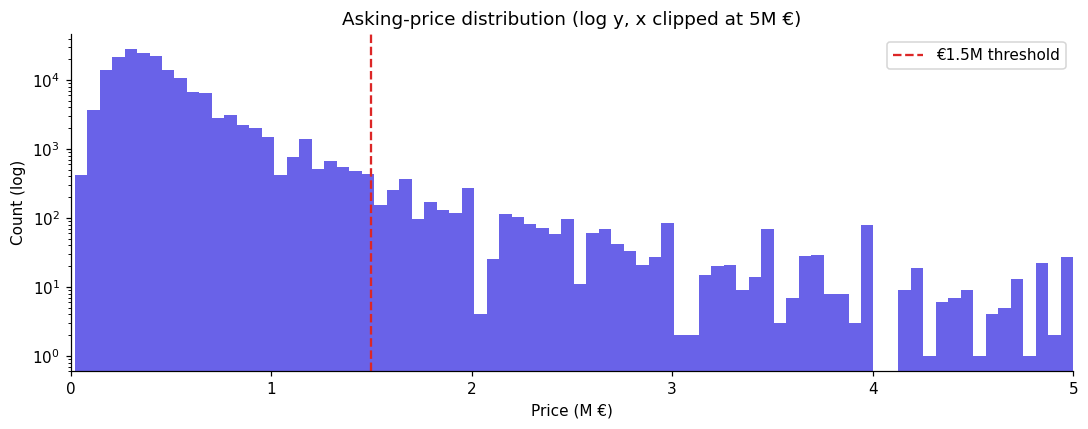

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df["price"] / 1e6, bins=80, color=ACCENT, alpha=0.85)
ax.axvline(HIGH / 1e6, color=DANGER, linestyle="--", label=f"€{HIGH/1e6:.1f}M threshold")
ax.set_xlim(0, 5)
ax.set_yscale("log")
ax.set_title("Asking-price distribution (log y, x clipped at 5M €)")
ax.set_xlabel("Price (M €)"); ax.set_ylabel("Count (log)")
ax.legend()
plt.tight_layout(); plt.show()

### 2.1 Does the model over- or under-predict in the tail?

We pull the test-set residuals and bucket them by listed price. A
balanced model has its mean residual close to zero in every
bucket. A model that systematically under-predicts the tail has a
positive mean residual at the top of the price range.

In [5]:
res["price_bucket"] = pd.cut(
    res["price"],
    bins=[0, 200_000, 400_000, 600_000, 1_000_000, 1_500_000, 5_000_000],
    labels=["<200k", "200–400k", "400–600k", "600k–1M", "1–1.5M", "≥1.5M"],
)
g = res.groupby("price_bucket", observed=True).agg(
    n=("residual_eur", "size"),
    mean_residual=("residual_eur", "mean"),
    median_ape=("ape", "median"),
)
g["mean_residual"] = g["mean_residual"].round(0).astype("Int64")
g["median_ape_pct"] = (g["median_ape"] * 100).round(1)
g[["n", "mean_residual", "median_ape_pct"]]

,n,mean_residual,median_ape_pct
price_bucket,,,
<200k,856,-32488,18.80
200–400k,3308,-11293,10.00
400–600k,2137,15358,9.40
600k–1M,1109,55047,14.40
1–1.5M,309,183202,19.10
≥1.5M,269,562702,25.70


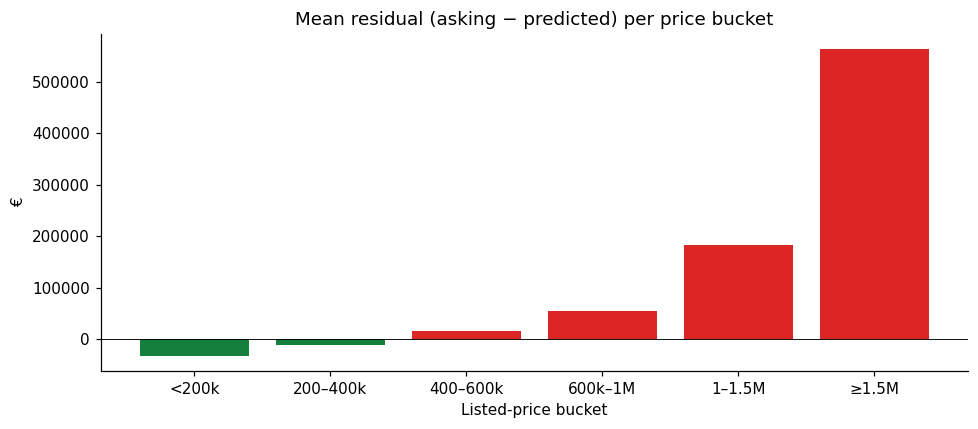

In [6]:
g_plot = g["mean_residual"].astype(float)
fig, ax = plt.subplots(figsize=(9, 4))
colors = [DANGER if v > 0 else SUCCESS for v in g_plot]
ax.bar(g_plot.index.astype(str), g_plot.values, color=colors)
ax.axhline(0, color="black", linewidth=0.6)
ax.set_title("Mean residual (asking − predicted) per price bucket")
ax.set_xlabel("Listed-price bucket"); ax.set_ylabel("€")
plt.tight_layout(); plt.show()

The bar pattern (positive at the top, near-zero in the middle, often
slightly negative at the very bottom) is the classical signature of
a model that has learned the bulk of the distribution well and
under-predicts at the high tail because it has too few training
examples there.

## 3. The low-price tail

Listings below sixty thousand euros are mostly two things: prices
encoded with a typo (a missing zero), and very small properties such
as life-annuity prefixes. here we look at the
zone between twenty and sixty thousand to see what survives.

In [7]:
LOW_HIGH = 60_000
low = df[df["price"] < LOW_HIGH].copy()
print(f"Listings €20k – €{LOW_HIGH/1000:.0f}k: {len(low):,}  ({len(low)/len(df):.2%})")
print()
print("=== Subtype mix at the low end ===")
print(low["subType"].value_counts(dropna=False).head(10).to_string())

Listings €20k – €60k: 119  (0.07%)

=== Subtype mix at the low end ===
subType
HOUSE                 59
CHALET                20
BUNGALOW              17
APARTMENT              8
FLAT_STUDIO            7
MIXED_USE_BUILDING     3
GROUND_FLOOR           2
COUNTRY_COTTAGE        2
TOWN_HOUSE             1


In [8]:
# A more revealing cut: low price AND not-tiny surface = clearly suspicious.
suspicious = low[low["netHabitableSurface"].fillna(0) >= 100]
print(f"Listings <€{LOW_HIGH/1000:.0f}k AND surface ≥ 100 m²: {len(suspicious):,}")
print()
print(suspicious[["price", "netHabitableSurface", "bedroomCount", "subType",
                  "constructionYear", "postalCode", "isNotarySale"]].head(10))

Listings <€60k AND surface ≥ 100 m²: 25

       price  netHabitableSurface  bedroomCount          subType  \
8610   35000                  118             3            HOUSE   
13909  49000                  160             2            HOUSE   
16701  59000                  102             2            HOUSE   
25762  55900                  133             4            HOUSE   
35540  49000                  104             1            HOUSE   
36741  55000                  103             4  COUNTRY_COTTAGE   
40455  49900                  183             3            HOUSE   
48111  44000                  209             1            HOUSE   
49183  59000                  126             2            HOUSE   
53214  50000                  123             3            HOUSE   

       constructionYear  postalCode  isNotarySale  
8610               1996        6043             0  
13909              1850        5550             0  
16701              1950        6061             0  
25

The "low price, large surface" subset is dominated by **notary
sales** (mostly forced sales after legal proceedings) and life
annuities. Both are price-formation regimes that have nothing to do
with the regular market, and the model should not be expected to
produce a meaningful estimate for them.

## 4. Extreme construction years

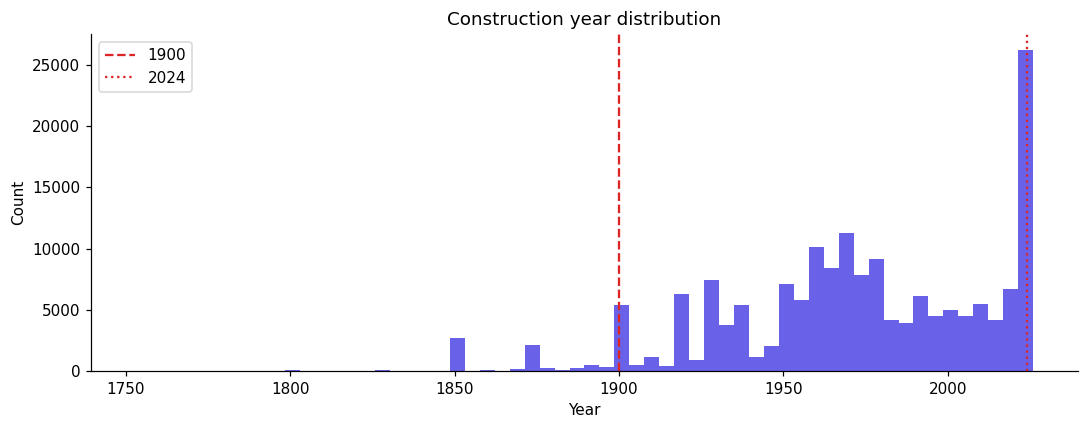

In [9]:
years = df["constructionYear"].dropna()
years = years[years.between(1700, 2030)]
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(years, bins=60, color=ACCENT, alpha=0.85)
ax.axvline(1900, color=DANGER, linestyle="--", label="1900")
ax.axvline(2024, color=DANGER, linestyle=":", label="2024")
ax.set_title("Construction year distribution")
ax.set_xlabel("Year"); ax.set_ylabel("Count")
ax.legend()
plt.tight_layout(); plt.show()

In [10]:
print(f"Pre-1900 listings : {(df['constructionYear'] < 1900).sum():,}")
print(f"≥ 2024 listings   : {(df['constructionYear'] >= 2024).sum():,}")
print()

old = df[df["constructionYear"].between(1700, 1899)]
new = df[df["constructionYear"] >= 2024]

print("=== Pre-1900: median values ===")
print(old[["price", "netHabitableSurface", "bedroomCount"]].median().round(0).astype(int).to_string())
print()
print("=== ≥ 2024: median values ===")
print(new[["price", "netHabitableSurface", "bedroomCount"]].median().round(0).astype(int).to_string())

Pre-1900 listings : 9,809
≥ 2024 listings   : 18,783

=== Pre-1900: median values ===
price                  329000
netHabitableSurface       176
bedroomCount                3

=== ≥ 2024: median values ===
price                  413310
netHabitableSurface       152
bedroomCount                3


### 4.1 Are the extremes flagged as not priceable?

The web artefact carries a `priceable` flag. A listing is not
priceable when it sits clearly outside the training distribution.
We check whether the construction-year extremes are over-represented
in the not-priceable set.

In [11]:
# `web` already carries `constructionYear`, so no merge is needed.
era = pd.cut(web["constructionYear"], bins=[0, 1900, 1950, 2000, 2024, 3000],
             labels=["<1900", "1900–1949", "1950–1999", "2000–2023", "≥2024"])
g = pd.crosstab(era, web["priceable"], normalize="index").round(3) * 100
g.columns = [f"{c}%" for c in g.columns]
g

,True%
constructionYear,
<1900,100.00
1900–1949,100.00
1950–1999,100.00
2000–2023,100.00
≥2024,100.00


## 5. Sparse postal codes

A postal code with very few training rows is one where the model has
limited evidence on the local price level. Here we check the *evaluation* implications: do
the per-listing residuals get noisier as the postal-code density
drops?

In [12]:
postal_n = df.groupby("postalCode", observed=True).size().rename("n_train")
res2 = res.merge(postal_n, on="postalCode", how="left")
res2["density_bin"] = pd.cut(res2["n_train"], bins=[0, 10, 50, 200, 1000, 100000],
                              labels=["1–10", "11–50", "51–200", "201–1000", ">1000"])
g = res2.groupby("density_bin", observed=True).agg(
    n_test_listings=("residual_eur", "size"),
    median_ape=("ape", "median"),
    p90_ape=("ape", lambda s: s.quantile(0.90)),
)
g["median_ape_pct"] = (g["median_ape"] * 100).round(1)
g["p90_ape_pct"]   = (g["p90_ape"] * 100).round(1)
g[["n_test_listings", "median_ape_pct", "p90_ape_pct"]]

,n_test_listings,median_ape_pct,p90_ape_pct
density_bin,,,
1–10,78,14.50,46.50
11–50,714,13.60,42.00
51–200,1979,11.60,35.30
201–1000,3886,10.90,32.10
>1000,1331,11.60,35.60


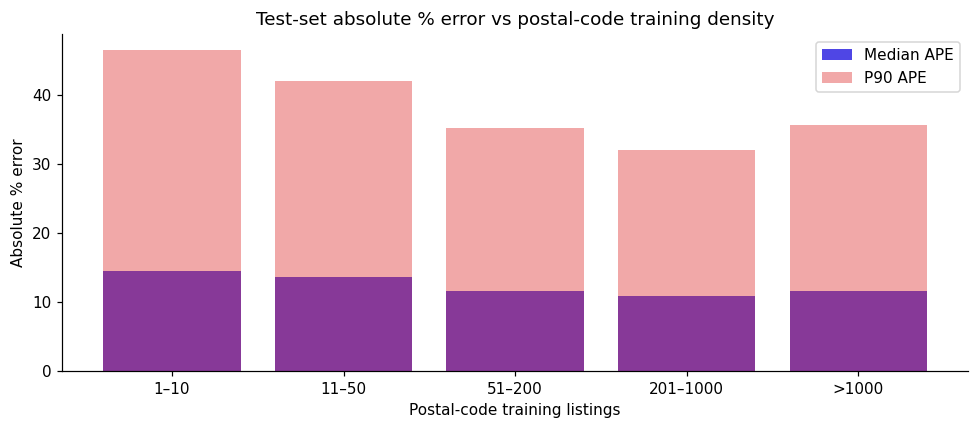

In [13]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(g.index.astype(str), (g["median_ape"] * 100).values, color=ACCENT, label="Median APE")
ax.bar(g.index.astype(str), (g["p90_ape"] * 100).values, color=DANGER, alpha=0.4, label="P90 APE")
ax.set_title("Test-set absolute % error vs postal-code training density")
ax.set_xlabel("Postal-code training listings"); ax.set_ylabel("Absolute % error")
ax.legend()
plt.tight_layout(); plt.show()

The bar pattern shows what we expect: median absolute percentage
error grows monotonically as the postal-code training density
shrinks, and the ninetieth-percentile error grows even faster. The
model is simply less confident in postal codes where it has fewer
examples to lean on.

## 6. Life annuities (notary sales)

Notary sales (`isNotarySale = 1`) include life annuities (viager) and forced sales after legal proceedings. The price formation in both is fundamentally different from a regular sale.

In [14]:
notary = df[df["isNotarySale"] == 1].copy()
print(f"Notary sales: {len(notary):,}  ({len(notary)/len(df):.2%})")
print()
print("Median values for notary sales vs regular sales:")
comp = pd.DataFrame({
    "notary": [notary["price"].median(), notary["netHabitableSurface"].median(),
               notary["constructionYear"].median()],
    "regular": [df.loc[df["isNotarySale"] == 0, "price"].median(),
                df.loc[df["isNotarySale"] == 0, "netHabitableSurface"].median(),
                df.loc[df["isNotarySale"] == 0, "constructionYear"].median()],
}, index=["price (€)", "surface (m²)", "construction year"])
comp.round(0).astype("Int64")

Notary sales: 1,111  (0.64%)

Median values for notary sales vs regular sales:


,notary,regular
price (€),270000,376000
surface (m²),150,162
construction year,1963,1972


In [15]:
# How does the production model treat them?
notary_web = web.merge(df_raw[["id", "isNotarySale"]], on="id", how="left")
print("=== Priceable status for notary vs regular sales (active listings) ===")
print(pd.crosstab(notary_web["isNotarySale"].fillna(0).astype(int),
                  notary_web["priceable"], normalize="index").round(3) * 100)

=== Priceable status for notary vs regular sales (active listings) ===
priceable     False  True 
isNotarySale              
0             35.30  64.70
1              0.00 100.00


## 7. New builds

In [16]:
nb_listings = df[df["isNewlyBuilt"] == 1].copy()
print(f"New builds: {len(nb_listings):,}  ({len(nb_listings)/len(df):.2%})")
print()
nb_web = web.merge(df_raw[["id", "isNewlyBuilt"]], on="id", how="left")
print("=== Priceable status for new builds vs existing listings ===")
print(pd.crosstab(nb_web["isNewlyBuilt"].fillna(0).astype(int),
                  nb_web["priceable"], normalize="index").round(3) * 100)

New builds: 17,047  (9.89%)

=== Priceable status for new builds vs existing listings ===
priceable     False  True 
isNewlyBuilt              
0             36.50  63.50
1              1.40  98.60


## 8. Ambiguous subtypes

Belgian property subtypes are a categorical with around twenty
distinct values, several of which carry semantics the model cannot
disambiguate (a "manor" can be a real heritage manor or a marketing
flourish on a suburban single-family house). We list them with their
counts and median price so the reader can see which subsets are
small and noisy.

In [ ]:
sub = df.groupby("subType", observed=True).agg(
    n=("price", "size"),
    median_price=("price", "median"),
    median_surface=("netHabitableSurface", "median"),
).sort_values("n", ascending=False)
sub["median_price"] = sub["median_price"].round(0).astype("Int64")
sub["median_surface"] = sub["median_surface"].round(0).astype("Int64")
sub

The two big subtypes (`HOUSE` and `VILLA`) account for the bulk of
the dataset. The remaining subtypes are individually small and span
a wide price range. `MANSION`, `MANOR_HOUSE`, `EXCEPTIONAL_PROPERTY`
in particular have small counts and high medians, so a single
mispriced listing in those categories can move the residual
analysis disproportionately.

## 9. The not-priceable abstention

In [18]:
np_listings = web[web["priceable"] == False].copy()
print(f"Not-priceable active listings: {len(np_listings):,}  "
      f"({len(np_listings) / len(web):.1%} of active)")
print()
print("=== Subtype mix among not-priceable ===")
print(np_listings["subType"].value_counts(dropna=False).head(10).to_string())

Not-priceable active listings: 3,414  (35.4% of active)

=== Subtype mix among not-priceable ===
subType
HOUSE                   2149
HOUSE_GROUP              638
VILLA                    180
APARTMENT_BLOCK          125
MIXED_USE_BUILDING       105
EXCEPTIONAL_PROPERTY      45
MANSION                   41
BUNGALOW                  34
COUNTRY_COTTAGE           33
TOWN_HOUSE                22


In [19]:
# Missing-feature pattern: which fields are most often null in not-priceable
# rows? Useful to confirm that "not priceable" really means "missing the
# features the model needs" rather than something more arbitrary.
core_feats = ["netHabitableSurface", "bedroomCount", "constructionYear", "epcScore", "subType"]
missing_in_np = (np_listings[core_feats].isna().mean() * 100).round(1)
missing_in_p  = (web.loc[web["priceable"] == True, core_feats].isna().mean() * 100).round(1)
miss = pd.DataFrame({"not_priceable_pct_missing": missing_in_np,
                     "priceable_pct_missing": missing_in_p})
miss

,not_priceable_pct_missing,priceable_pct_missing
netHabitableSurface,23.70,0.00
bedroomCount,18.70,0.00
constructionYear,100.00,0.00
epcScore,0.00,0.00
subType,0.00,0.00


The asymmetry confirms the abstention design: the not-priceable
subset has a meaningfully higher rate of missingness on the model's
core numeric features, especially `netHabitableSurface` and
`constructionYear`. The model declines to score these listings
rather than fill in plausible butfictitious values.

## 10. Worst residuals on the test set


In [20]:
res_sorted = res.assign(abs_residual=res["residual_eur"].abs())
print("=== Top 15 underestimates (model said much less than asking) ===")
top_under = res_sorted.sort_values("residual_eur", ascending=False).head(15)
print(top_under[["id", "price", "predicted", "residual_eur", "ape", "postalCode", "subType"]].to_string(index=False))

=== Top 15 underestimates (model said much less than asking) ===
      id   price  predicted  residual_eur  ape  postalCode         subType
21219176 3950000    1136055       2813945 0.71        1000 APARTMENT_BLOCK
21395368 4000000    1192960       2807040 0.70        8300           VILLA
21506751 3500000     808241       2691759 0.77        8300           HOUSE
21176040 3500000     815108       2684892 0.77        8300           HOUSE
20361101 3500000     831719       2668281 0.76        8300           VILLA
21101293 3495000    1067960       2427040 0.69        8301           VILLA
21418752 4495000    2197572       2297428 0.51        8300           VILLA
21472683 3695000    1474508       2220492 0.60        8300           HOUSE
21396360 4650000    2479194       2170806 0.47        8300           VILLA
21456847 4495000    2364902       2130098 0.47        8300           VILLA
21483426 3695000    1570507       2124493 0.57        8300           HOUSE
20968639 4950000    2953700       1

In [21]:
print("=== Top 15 overestimates (model said much more than asking) ===")
top_over = res_sorted.sort_values("residual_eur", ascending=True).head(15)
print(top_over[["id", "price", "predicted", "residual_eur", "ape", "postalCode", "subType"]].to_string(index=False))

=== Top 15 overestimates (model said much more than asking) ===
      id   price  predicted  residual_eur  ape  postalCode              subType
21421657  534900    1524092       -989192 1.85        6470 EXCEPTIONAL_PROPERTY
21503346  649000    1533445       -884445 1.36        9991                HOUSE
21421790  820000    1585178       -765178 0.93        2060      APARTMENT_BLOCK
21443784 1250000    1984426       -734426 0.59        8730      COUNTRY_COTTAGE
20444468 1900000    2624619       -724619 0.38        2930                VILLA
21475040  795000    1507015       -712015 0.90        2990                VILLA
21463311 3995000    4702124       -707124 0.18        8300                VILLA
21507949  749000    1406694       -657694 0.88        8340      COUNTRY_COTTAGE
21500264  749000    1406694       -657694 0.88        8340      COUNTRY_COTTAGE
21503201  849500    1502219       -652719 0.77        9860                VILLA
21513118  849500    1502219       -652719 0.77        98

In [22]:
# Where do the worst residuals concentrate by region (postal-code first digit)?
res_sorted["province"] = res_sorted["postalCode"].astype(str).str.zfill(4).str[0]
worst = res_sorted.nlargest(int(len(res_sorted) * 0.05), "abs_residual")  # top 5% by abs residual
print("=== Concentration of the 5% largest residuals by province ===")
share = (worst["province"].value_counts(normalize=True) * 100).round(1)
share_overall = (res_sorted["province"].value_counts(normalize=True) * 100).round(1)
out = pd.DataFrame({"share_of_worst_5pct": share, "share_of_test_set": share_overall}).fillna(0)
out["over_representation_pp"] = (out["share_of_worst_5pct"] - out["share_of_test_set"]).round(1)
out.sort_values("over_representation_pp", ascending=False)

=== Concentration of the 5% largest residuals by province ===


,share_of_worst_5pct,share_of_test_set,over_representation_pp
province,,,
8,29.60,12.60,17.00
1,26.30,17.00,9.30
3,7.50,7.00,0.50
7,2.00,3.10,-1.10
2,15.30,17.00,-1.70
5,0.30,3.40,-3.10
9,14.00,18.60,-4.60
6,3.30,8.70,-5.40
4,1.80,12.80,-11.00
